### Loading processed datasets

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)

# Load data
X_train = pd.read_csv("../outputs/X_train_processed.csv")
X_test = pd.read_csv("../outputs/X_test_processed.csv")
y_train = pd.read_csv("../outputs/y_train.csv").values.ravel()
y_test = pd.read_csv("../outputs/y_test.csv").values.ravel()

### Creating Evaluation Function

In [10]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(f"--- {model_name} Results ---")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")
    
    return {"Model": model_name, "ROC-AUC": roc_auc, "PR-AUC": pr_auc}

### Training Baseline Model

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Baseline: Only using TransactionAmt
scaler = StandardScaler()
X_train_amt = scaler.fit_transform(X_train[["TransactionAmt"]])
X_test_amt = scaler.transform(X_test[["TransactionAmt"]])

baseline_model = LogisticRegression(class_weight="balanced")
baseline_model.fit(X_train_amt, y_train)

baseline_results = evaluate_model(baseline_model, X_test_amt, y_test, "Baseline (Amount Only)")

--- Baseline (Amount Only) Results ---
ROC-AUC: 0.5004
PR-AUC:  0.0391


Full Model Training

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- STEP 1: Decision Tree ---
print("Training Decision Tree...")
dt = DecisionTreeClassifier(class_weight="balanced", max_depth=10, random_state=42)
dt.fit(X_train, y_train)

# --- STEP 2: Random Forest ---
print("Training Random Forest (this may take a minute)...")
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced", 
    n_jobs=-1, 
    max_depth=15,     
    random_state=42
)
rf.fit(X_train, y_train)

# --- STEP 3: XGBoost ---
print("Training XGBoost...")
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    scale_pos_weight=scale_weight, 
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42
)
xgb.fit(X_train, y_train)

print("All models trained successfully!")

Training Decision Tree...
Training Random Forest (this may take a minute)...
Training XGBoost...
All models trained successfully!


### Creating a model comparison table

In [28]:
all_results = []
all_results.append(evaluate_model(dt, X_test, y_test, "Decision Tree"))
all_results.append(evaluate_model(rf, X_test, y_test, "Random Forest"))
all_results.append(evaluate_model(xgb, X_test, y_test, "XGBoost"))

results_df = pd.DataFrame(all_results).sort_values(by="PR-AUC", ascending=False)
results_df.to_csv("../outputs/model_results.csv", index=False)
results_df

--- Decision Tree Results ---
ROC-AUC: 0.8639
PR-AUC:  0.4164
--- Random Forest Results ---
ROC-AUC: 0.9005
PR-AUC:  0.5692
--- XGBoost Results ---
ROC-AUC: 0.9230
PR-AUC:  0.6131


,Model,ROC-AUC,PR-AUC
2,XGBoost,0.923033,0.613092
1,Random Forest,0.900529,0.569216
0,Decision Tree,0.863898,0.416355


In [16]:
results.to_csv("../outputs/model_results.csv", index=False)

### Plot Precision-Recall Curve

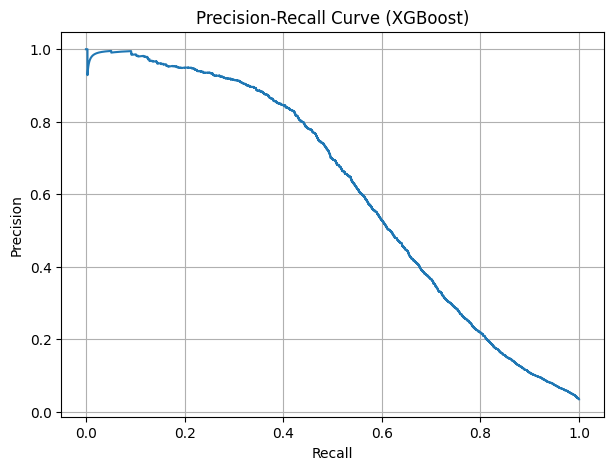

In [17]:
from sklearn.metrics import precision_recall_curve

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve (XGBoost)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

### Feature Importance Plot

C:\Users\katte\AppData\Local\Temp\ipykernel_14924\84085732.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(10), x="Importance", y="Feature", palette="magma")


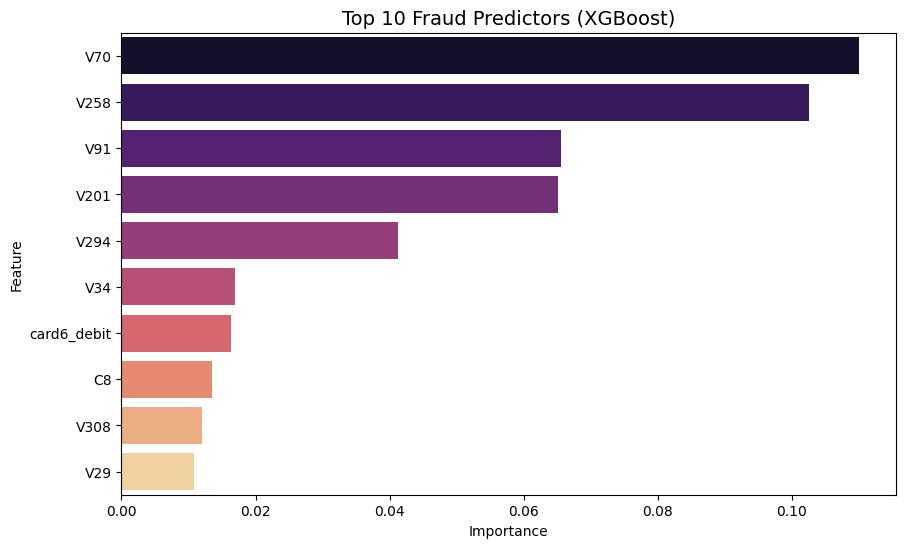

In [24]:
# Extracting feature importance from the best tree model (Random Forest or XGBoost)
best_model_name = results_df.iloc[0]["Model"]
model_to_use = rf if best_model_name == "Random Forest" else xgb

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_to_use.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.to_csv("../outputs/feature_importance.csv", index=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10), x="Importance", y="Feature", palette="magma")
plt.title(f"Top 10 Fraud Predictors ({best_model_name})", fontsize=14)
plt.show()

In [21]:
importance.to_csv("../outputs/feature_importance.csv", index=False)

Visualizing the Impact of Feature Engineering

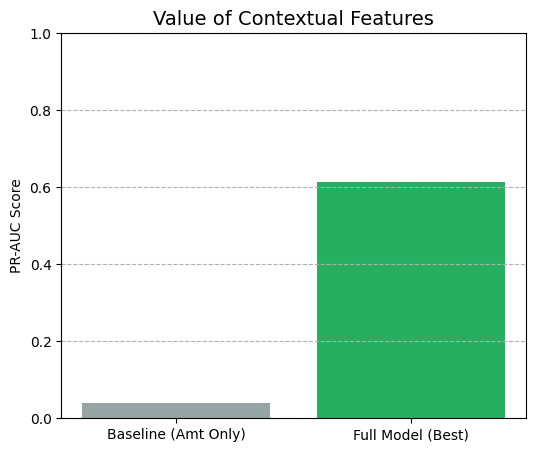

In [ ]:
# Comparison of Baseline vs Best Model
models = ["Baseline (Amt Only)", "Best Model"]
pr_scores = [baseline_results["PR-AUC"], results_df["PR-AUC"].max()]

plt.figure(figsize=(6,5))
plt.bar(models, pr_scores, color=["#95a5a6", "#27ae60"])
plt.title("Value of Contextual Features", fontsize=14)
plt.ylabel("PR-AUC Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--")
plt.show()

Threshold Tuning

In [26]:
y_prob_best = model_to_use.predict_proba(X_test)[:, 1]
threshold = 0.2
y_pred_tuned = (y_prob_best >= threshold).astype(int)

from sklearn.metrics import precision_score, recall_score
print(f"Final Decision Threshold: {threshold}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")

Final Decision Threshold: 0.2
Precision: 0.0732
Recall:    0.9516


Lowering the threshold to 0.2 catches almost all fraud (95% recall) but results in many false positives (8.3% precision). In a real business case, we would need to balance the cost of manual review vs. the cost of fraud.

Model Camparison

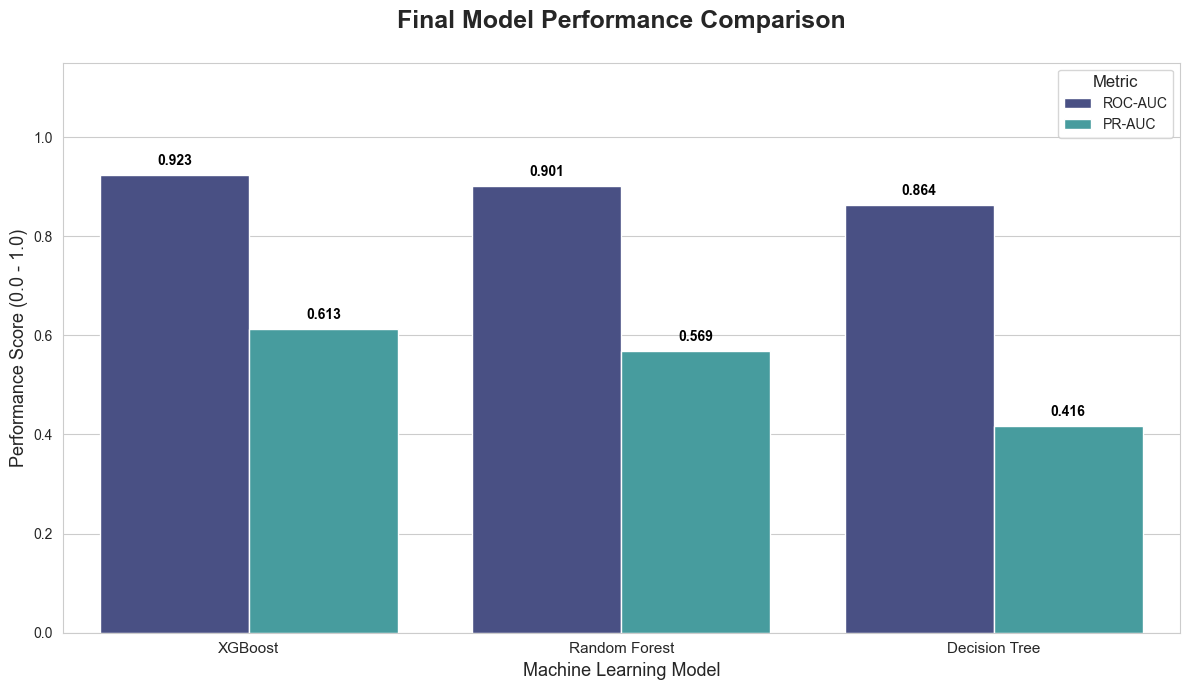

In [30]:
# 1. Load the results
results = pd.read_csv("../outputs/model_results.csv")

# 2. Reorganize data for grouped plotting
# This converts the table from "Wide" to "Long" format
results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")

# 3. Create the Visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Use a professional color palette (e.g., 'viridis' or 'coolwarm')
ax = sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="mako")

# 4. Add data labels on top of bars for a "presentation" look
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only label bars that exist
        ax.annotate(format(height, '.3f'), 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 10), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold', color='black')

# 5. Final Formatting
plt.title("Final Model Performance Comparison", fontsize=18, fontweight='bold', pad=25)
plt.ylim(0, 1.15) # Leave room for the labels on top
plt.ylabel("Performance Score (0.0 - 1.0)", fontsize=13)
plt.xlabel("Machine Learning Model", fontsize=13)
plt.xticks(fontsize=11)
plt.legend(title="Metric", title_fontsize='12', loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig("../outputs/final_model_comparison.png", dpi=300) # Save high-res for slides
plt.show()